# Visualise binding site designer

In [2]:
### Imports
import math
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd


### Functions

In [11]:
def count_designs_in_region(df, x_col, y_col, x_range, y_range):
    """
    Counts the number of points (designs) falling within the specified rectangle.
    """
    mask = (
        (df[x_col] >= x_range[0]) & (df[x_col] <= x_range[1]) &
        (df[y_col] >= y_range[0]) & (df[y_col] <= y_range[1])
    )
    return int(mask.sum())

def plot_scatter_with_region(df, x_col, y_col, x_range, y_range, xlim=None, ylim=None):
    """
    Plots a scatter plot, overlays a rectangle, and displays the count of designs within.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 1. Create the scatter plot
    ax.scatter(df[x_col], df[y_col], alpha=0.6, label='Data Points')
    
    # 2. Calculate rectangle parameters
    width = x_range[1] - x_range[0]
    height = y_range[1] - y_range[0]
    
    # 3. Create the rectangle patch
    rect = patches.Rectangle(
        (x_range[0], y_range[0]), 
        width, height, linewidth=2, 
        edgecolor='red', facecolor='red', alpha=0.2, label='Target Region'
    )
    ax.add_patch(rect)
    
    # 4. Count designs and add text box
    design_count = count_designs_in_region(df, x_col, y_col, x_range, y_range)
    text_str = f'Designs in region: {design_count}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    
    # transform=ax.transAxes places it relative to the axes (0.05 is 5% from left, 0.95 is 95% from bottom)
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)
    
    # 5. Apply Axis Limits
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    
    # Formatting
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'Scatter Plot: {x_col} vs {y_col}')
    ax.legend(loc='upper right') # Moved legend so it doesn't overlap text box
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()

def plot_multiple_scatters(df_list, titles, x_col, y_col, x_range, y_range, cols=3, xlim=None, ylim=None):
    """
    Creates a grid of subplots, highlighting a target region and counting valid designs.
    """
    n = len(df_list)
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), constrained_layout=True)
    
    if n > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    rect_width = x_range[1] - x_range[0]
    rect_height = y_range[1] - y_range[0]

    for i in range(n):
        ax = axes_flat[i]
        df = df_list[i]
        
        # Plot data
        ax.scatter(df[x_col], df[y_col], alpha=0.6, s=15)
        
        # Add the range patch
        rect = patches.Rectangle(
            (x_range[0], y_range[0]), rect_width, rect_height,
            linewidth=1.5, edgecolor='red', facecolor='red', alpha=0.15
        )
        ax.add_patch(rect)
        
        # Count designs and add text box
        design_count = count_designs_in_region(df, x_col, y_col, x_range, y_range)
        text_str = f'Valid: {design_count}'
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
        ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)
        
        # Apply Axis Limits
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)
        
        # Labels and Titles
        ax.set_title(titles[i])
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.grid(True, linestyle=':', alpha=0.6)

    # Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.show()

def plot_comparative_distributions(df_list, columns, df_labels=None, cols=2):
    """
    Plots distribution curves for specific columns across multiple dataframes.
    
    df_list: List of pandas DataFrames
    columns: List of column names to plot
    df_labels: List of names for the dataframes (for the legend)
    cols: Number of columns in the subplot grid
    """
    # 1. Setup Labels
    # If the user didn't provide names for the dataframes, generate generic ones
    if df_labels is None:
        df_labels = [f'Dataset {i+1}' for i in range(len(df_list))]
        
    if len(df_labels) != len(df_list):
        raise ValueError("Length of df_labels must match length of df_list")

    # 2. Setup Grid
    n_plots = len(columns)
    rows = math.ceil(n_plots / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4), constrained_layout=True)
    
    # Flatten axes for easy iteration, handle single plot case
    if n_plots > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    # 3. Plotting Loop
    for i, col_name in enumerate(columns):
        ax = axes_flat[i]
        
        # Iterate through every dataframe and add its curve to the current plot
        for j, df in enumerate(df_list):
            # Check if column exists in this dataframe
            if col_name in df.columns:
                # dropna is important for KDE calculations
                sns.kdeplot(
                    data=df, 
                    x=col_name, 
                    label=df_labels[j], 
                    ax=ax, 
                    fill=True, 
                    alpha=0.1
                )
        
        ax.set_title(f'Distribution of {col_name}')
        ax.set_xlabel(col_name)
        ax.set_ylabel('Density')
        ax.legend(title="Data Source")
        ax.grid(True, linestyle=':', alpha=0.5)

    # 4. Cleanup
    # Hide empty subplots if the grid is larger than the number of columns requested
    for k in range(i + 1, len(axes_flat)):
        axes_flat[k].axis('off')
        
    plt.show()

In [4]:
###  Statistics functions

def statistics_columns(df, col1, col2, paired=False, alpha=0.05, treshold = 0):
    x = df[col1].dropna().reset_index(drop=True)
    y = df[col2].dropna().reset_index(drop=True)
    # Ensure same length for paired tests
    if paired and len(x) != len(y):
        raise ValueError("For paired tests, both columns must have the same number of observations")

    # Normality tests
    p_norm_x = stats.shapiro(x)[1]
    p_norm_y = stats.shapiro(y)[1]
    normal = (p_norm_x > alpha) and (p_norm_y > alpha)

    # Determine which test to run
    if paired:
        if normal:
            test_stat, p = stats.ttest_rel(x, y)
            test_name = "Paired t-test"
            effect_size = (x - y).mean() / (x - y).std(ddof=1)  # Cohen's d for paired
        else:
            test_stat, p = stats.wilcoxon(x, y)
            test_name = "Wilcoxon signed-rank"
            effect_size = (x > y).mean() - (x < y).mean()  # Rank biserial
    else:
        # Check variance homogeneity
        equal_var = stats.levene(x, y).pvalue > alpha

        if normal:
            test_stat, p = stats.ttest_ind(x, y, equal_var=equal_var)
            test_name = "Unpaired t-test" if equal_var else "Welch’s t-test"
            # Pooled standard deviation
            pooled_std = np.sqrt(((len(x)-1)*np.std(x, ddof=1)**2 + (len(y)-1)*np.std(y, ddof=1)**2) / (len(x) + len(y) - 2))
            effect_size = (np.mean(x) - np.mean(y)) / pooled_std  # Cohen's d
        else:
            test_stat, p = stats.mannwhitneyu(x, y, alternative='two-sided')
            test_name = "Mann–Whitney U"
            # Rank biserial approximation
            n1, n2 = len(x), len(y)
            U = test_stat
            effect_size = 1 - (2 * U) / (n1 * n2)
    
    if p > 0.05 :
        star = "ns"
    elif p < 0.05 and p > 0.01 :
        star = "*"
    elif p < 0.01 and p > 0.001 :
        star = "**"
    else:
        star = "***"
    
    return {
        "test": test_name,
        "p_value": p,
        "star": star,
        "statistic": test_stat,
        f"mean {col1}" : np.mean(x),
        f"mean {col2}" : np.mean(y),
        f"over_treshold {col1}" : len(df[df[col1] > treshold]),
        f"over_treshold {col2}" : len(df[df[col2] > treshold]),
        f"times {col1} > {col2}" : (df[col1] > df[col2]).sum(),
        f"times {col2} > {col1}" : (df[col2] > df[col1]).sum(),
        "mean_difference": np.mean(x) - np.mean(y),
        "effect_size": effect_size,
        "normality": {"col1": p_norm_x, "col2": p_norm_y},
        "equal_variance": equal_var if not paired else None
    }

### Load dataframes to visualise

In [21]:
# Paths
ESM_path = "/home/eduardo/allostery/2XPU_trial/ESM_filtered_df.csv"
AF3_w_MSA_path = ""
AF3_wo_MSA_path = "/home/eduardo/allostery/2XPU_trial/AF3_predictions.csv"
AF3_w_template_path = ""
AF3_w_MSA_w_template_path = ""
Chai_w_MSA_path = ""
Chai_wo_MSA_path = "/home/eduardo/allostery/2XPU_trial/CHAI_predictions.csv"
Chai_w_template_path = ""
Chai_w_MSA_w_template_path = ""
Boltz_w_MSA_path = ""
Boltz_wo_MSA_path = ""
Boltz_template_path = ""
Boltz_w_MSA_w_template_path = ""


In [22]:
# Load dataframes
ESM_df = pd.read_csv(ESM_path)
Chai_wo_MSA_df= pd.read_csv(Chai_wo_MSA_path)
AF3_wo_MSA_df= pd.read_csv(AF3_wo_MSA_path)

# Experiments

### Small plot trial

In [17]:
print(ESM_df.columns.tolist())
print(Chai_wo_MSA_df.columns.tolist())

['file_ID', 'sequence', 'pLDDT_mean', 'pLDDT_std', 'RMSD', 'TMscore', 'num_clashes', 'clashes_per_atom', 'Gnina_CNNscore', 'Gnina_affinity', 'pLDDT_mean_norm', 'TMscore_norm', 'clashes_per_atom_norm', 'global_score']
['Unnamed: 0', 'file_ID', 'sequence', 'pLDDT_mean', 'pLDDT_std', 'RMSD', 'TMscore', 'num_clashes', 'clashes_per_atom', 'Gnina_CNNscore', 'Gnina_affinity']


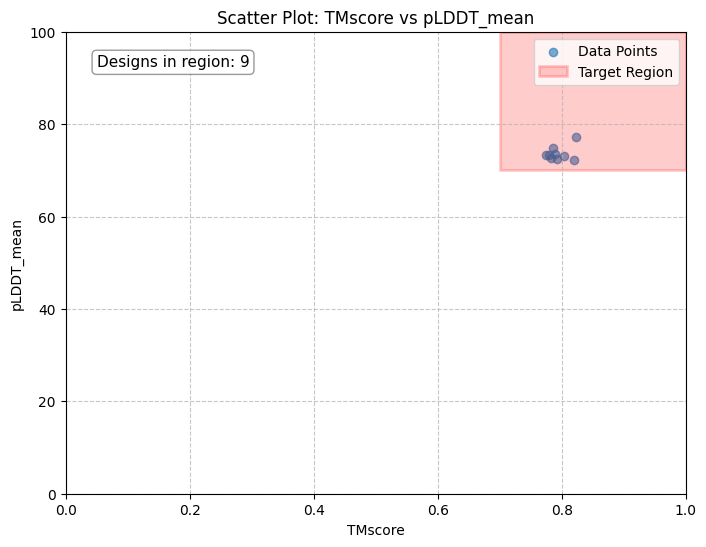

In [18]:
plot_scatter_with_region(ESM_df, 'TMscore', 'pLDDT_mean', [0.7,1], [70,100], xlim=[0,1], ylim=[0,100])

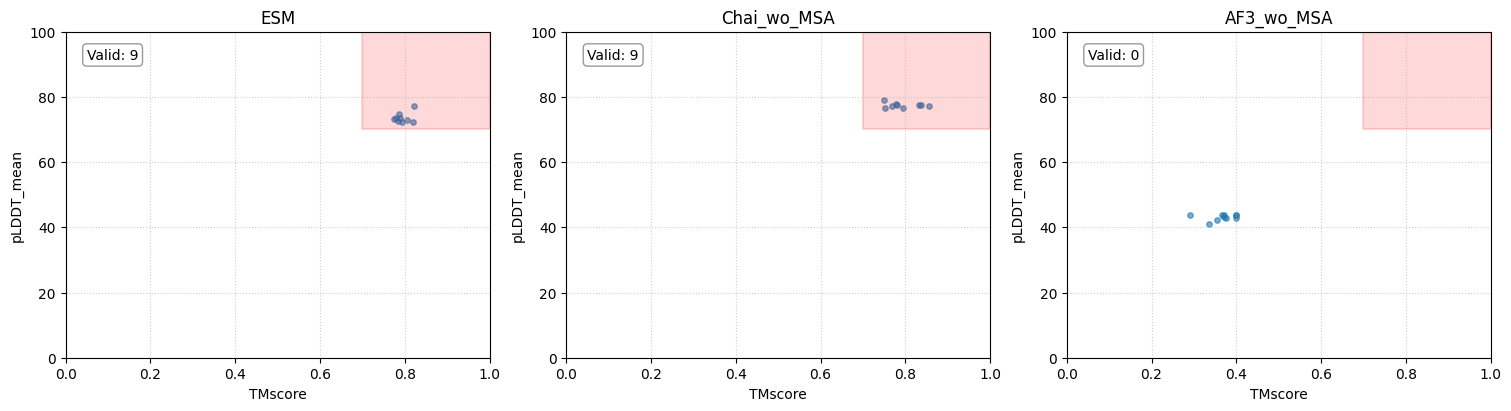

In [23]:
plot_multiple_scatters([ESM_df, Chai_wo_MSA_df, AF3_wo_MSA_df], ['ESM', 'Chai_wo_MSA', 'AF3_wo_MSA'], 'TMscore', 'pLDDT_mean', [0.7,1], [70,100], xlim=[0,1], ylim=[0,100], cols=3)

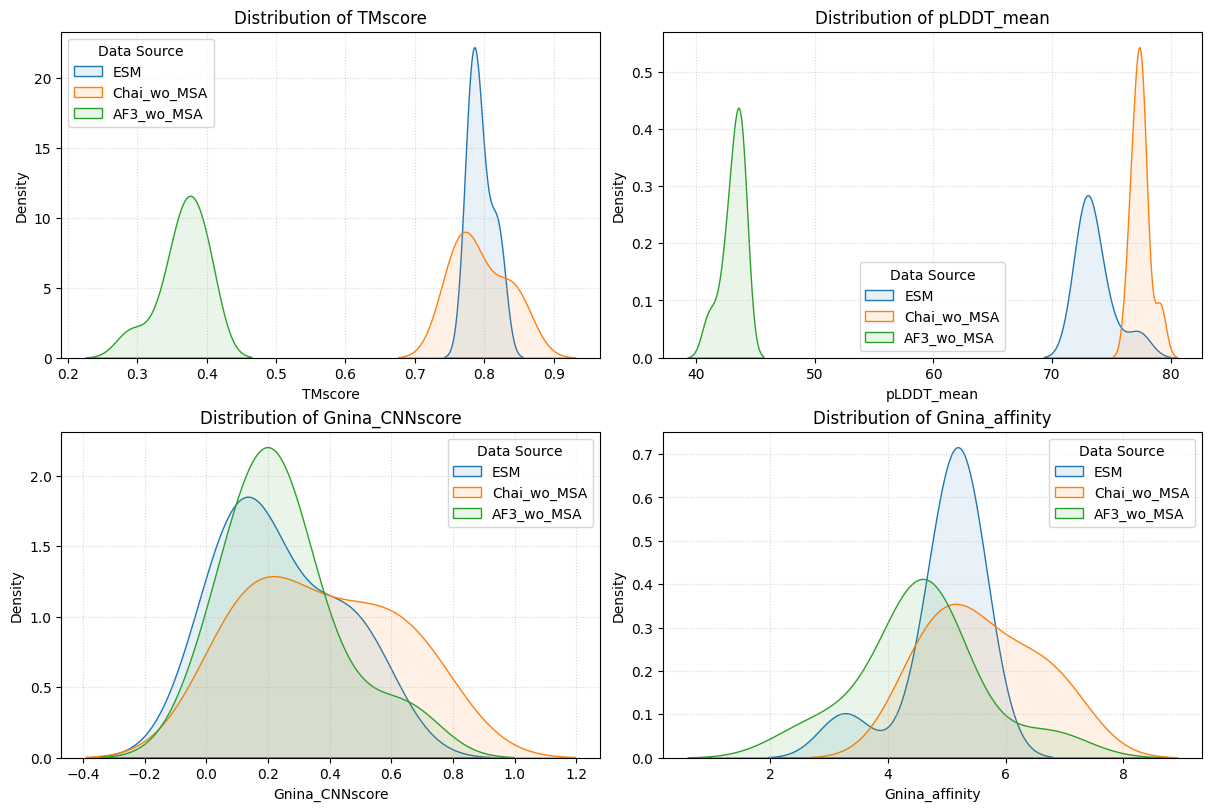

In [25]:
plot_comparative_distributions([ESM_df, Chai_wo_MSA_df,AF3_wo_MSA_df], ['TMscore', 'pLDDT_mean', 'Gnina_CNNscore', 'Gnina_affinity'], df_labels=['ESM', 'Chai_wo_MSA', 'AF3_wo_MSA'], cols=2)

### 